In [6]:
library(dplyr)
library(zoo)

nasa_ntl <- read.csv("NASA_ntl_2012_2024_monthly.csv", stringsAsFactors = FALSE)

nasa_ntl <- nasa_ntl %>%
    mutate(date = as.Date(paste0(date, "-01"), format = "%Y-%m-%d"))

nasa_ntl_odd <- nasa_ntl %>%
    filter(as.numeric(format(date, "%m")) %in% c(1, 3, 5, 7, 9, 11))

vancouver_ntl <- nasa_ntl_odd %>%
    group_by(date) %>%
    summarise(
        total_ntl = sum(n_non_na_pixels * ntl_mean, na.rm = TRUE),
        total_pixels = sum(n_non_na_pixels, na.rm = TRUE),
        .groups = "drop"
    ) %>%
    mutate(weighted_ntl_mean = total_ntl / total_pixels) %>%
    arrange(date) %>%
    mutate(
        prev_weighted_ntl_mean = lag(weighted_ntl_mean),
        total_ntl = 100 * (weighted_ntl_mean - prev_weighted_ntl_mean) / prev_weighted_ntl_mean
    )

write.csv(vancouver_ntl, "ntl_vancouver_monthly_total_ntl.csv", row.names = FALSE)

print(vancouver_ntl)


# A tibble: 78 × 5
   date       total_ntl total_pixels weighted_ntl_mean prev_weighted_ntl_mean
   <date>         <dbl>        <int>             <dbl>                  <dbl>
 1 2012-01-01     NA            3650              4.52                  NA   
 2 2012-03-01      9.51         3853              4.95                   4.52
 3 2012-05-01     -3.79         3868              4.76                   4.95
 4 2012-07-01      1.88         3868              4.85                   4.76
 5 2012-09-01      9.77         3868              5.33                   4.85
 6 2012-11-01    -24.6          3434              4.02                   5.33
 7 2013-01-01    -13.9          3862              3.46                   4.02
 8 2013-03-01     78.6          3861              6.18                   3.46
 9 2013-05-01     -5.98         3865              5.81                   6.18
10 2013-07-01      2.81         3825              5.97                   5.81
# ℹ 68 more rows


In [2]:
library(tidyverse)

Warning message:
"package 'tidyverse' was built under R version 4.4.2"


Warning message:
"package 'ggplot2' was built under R version 4.4.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
data <- read_csv('ntl_vancouver_monthly_pct_change.csv')

data$date <- as.Date(paste("01", data$date), format = "%d %b %Y")

data <- data[order(data$date), ]
data <- na.omit(data)
data$date <- as.Date(data$date, format = "%Y-%m-%d")

data$time_index <- seq_len(nrow(data))

bp_model <- breakpoints(total_ntl ~ time_index, data = data, h = 0.10)

summary(bp_model)

plot(bp_model)

fitted_vals <- fitted(bp_model)

break_inds <- bp_model$breakpoints

break_dates <- data$date[break_inds]

print(break_dates)

plot(data$date, data$total_ntl, type = "l",
     xlab = "Date", ylab = "Total NTL",
     main = "total_ntl with Structural Breaks (Trend Model)")
lines(data$date, fitted_vals, col = "red", lwd = 2)

break_inds <- bp_model$breakpoints 
break_dates <- data$date[break_inds]
abline(v = break_dates, col = "blue", lty = 2)

Rows: 78 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): date
dbl (5): total_ntl, total_pixels, weighted_ntl_mean, prev_weighted_ntl_mean,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ERROR: Error in breakpoints(total_ntl ~ time_index, data = data, h = 0.1): could not find function "breakpoints"


Rows: 78 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): date
dbl (5): total_ntl, total_pixels, weighted_ntl_mean, prev_weighted_ntl_mean,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.



	 Optimal (m+1)-segment partition: 

Call:
breakpoints.formula(formula = total_ntl ~ time_index, h = 0.2, 
    data = data)

Breakpoints at observation number:
                   
m = 1   16         
m = 2         42 60
m = 3   16    42 60
m = 4   15 30 45 60

Corresponding to breakdates:
                                                                              
m = 1   0.207792207792208                                                     
m = 2                                      0.545454545454545 0.779220779220779
m = 3   0.207792207792208                  0.545454545454545 0.779220779220779
m = 4   0.194805194805195 0.38961038961039 0.584415584415584 0.779220779220779

Fit:
                                                     
m   0         1         2         3         4        
RSS 572610254 547360460 515274335 492184773 491243905
BIC      1450      1459      1468      1477      1490

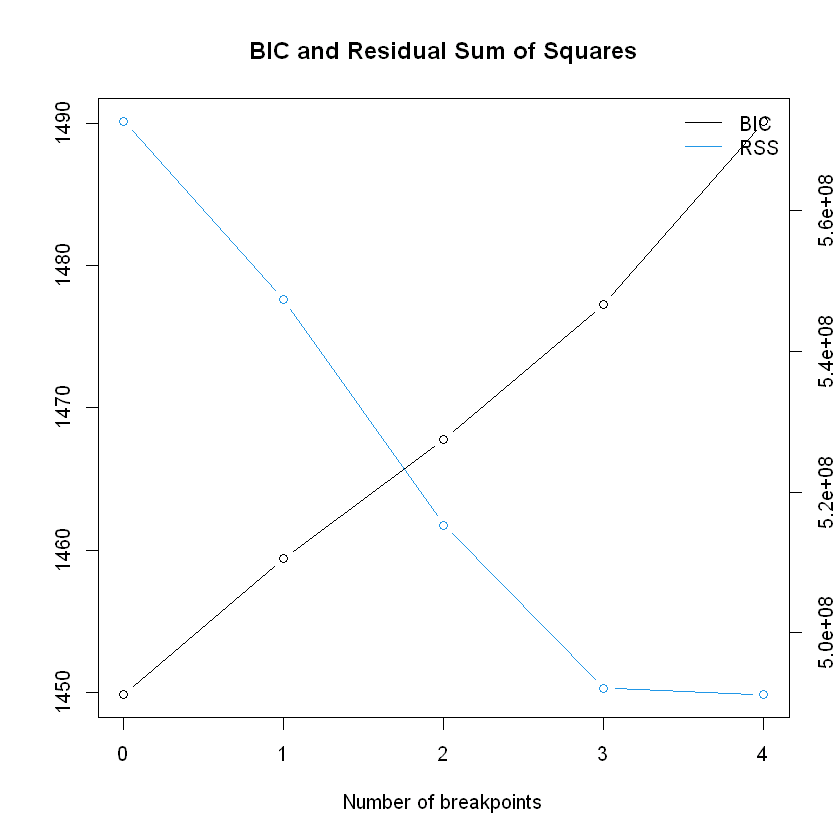

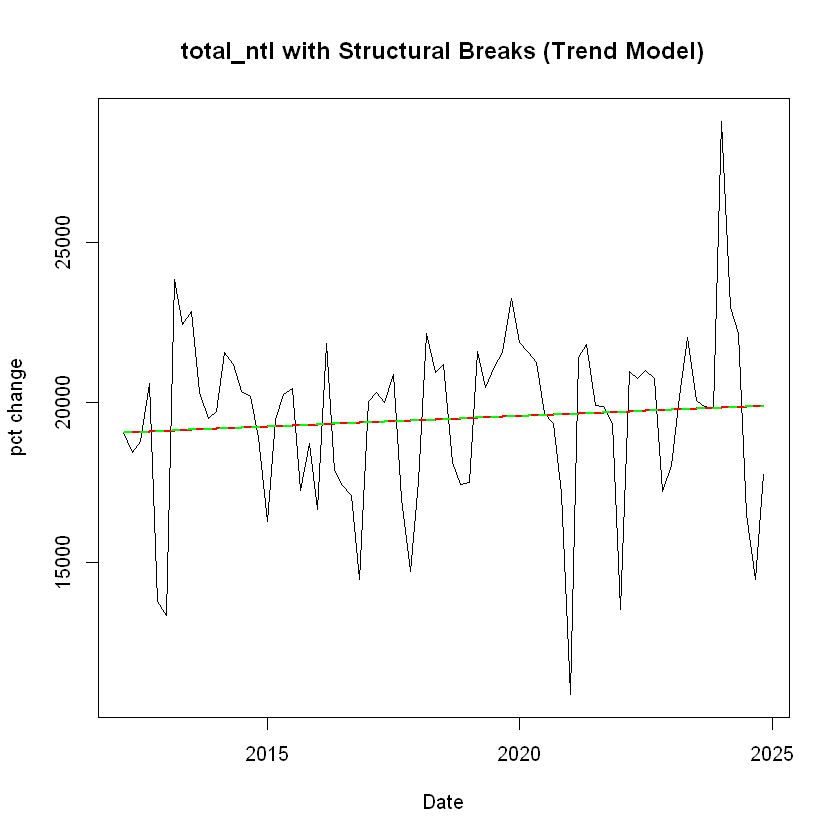

In [ ]:

# 1. Read your CSV file
data <- read_csv('ntl_vancouver_monthly_pct_change.csv')

data$date <- as.yearmon(data$date, "%b %Y")
data$date <- as.Date(data$date)  
data <- data[order(data$date), ]
data <- na.omit(data)

data$time_index <- seq_len(nrow(data))

bp_model <- breakpoints(total_ntl ~  time_index, data = data, h = 0.20)
summary(bp_model)

fitted_vals <- fitted(bp_model, x = data$time_index)

plot(bp_model)

plot(data$date, data$total_ntl, type = "l",
     xlab = "Date", ylab = "pct change",
     main = "total_ntl with Structural Breaks (Trend Model)")
lines(data$date, fitted_vals, col = "red", lwd = 2)

break_inds <- bp_model$breakpoints    

text(x = break_dates, 
     y = fitted_vals[break_inds], 
     labels = as.character(break_dates), 
     pos = 3, col = "blue")
abline(v = break_dates, col = "blue", lty = 2)

simple_model <- lm(total_ntl ~ time_index, data = data)

simple_pred <- predict(simple_model)

lines(data$date, simple_pred, col = "green", lwd = 2, lty = 2)




	 Optimal (m+1)-segment partition: 

Call:
breakpoints.formula(formula = total_ntl ~ time_index, h = 0.1, 
    data = data)

Breakpoints at observation number:
                               
m = 1         30               
m = 2         30       70      
m = 3      17 30       70      
m = 4      17 30    60 70      
m = 5      17 30 43 60 70      
m = 6      17 30 43 60 70    89
m = 7   10 20 30 43 60 70    89
m = 8   10 20 30 43 60 70 80 90

Corresponding to breakdates:
                                          
m = 1            0.3                      
m = 2            0.3          0.7         
m = 3       0.17 0.3          0.7         
m = 4       0.17 0.3      0.6 0.7         
m = 5       0.17 0.3 0.43 0.6 0.7         
m = 6       0.17 0.3 0.43 0.6 0.7     0.89
m = 7   0.1 0.2  0.3 0.43 0.6 0.7     0.89
m = 8   0.1 0.2  0.3 0.43 0.6 0.7 0.8 0.9 

Fit:
                                                                  
m   0      1      2      3      4      5      6      7      8

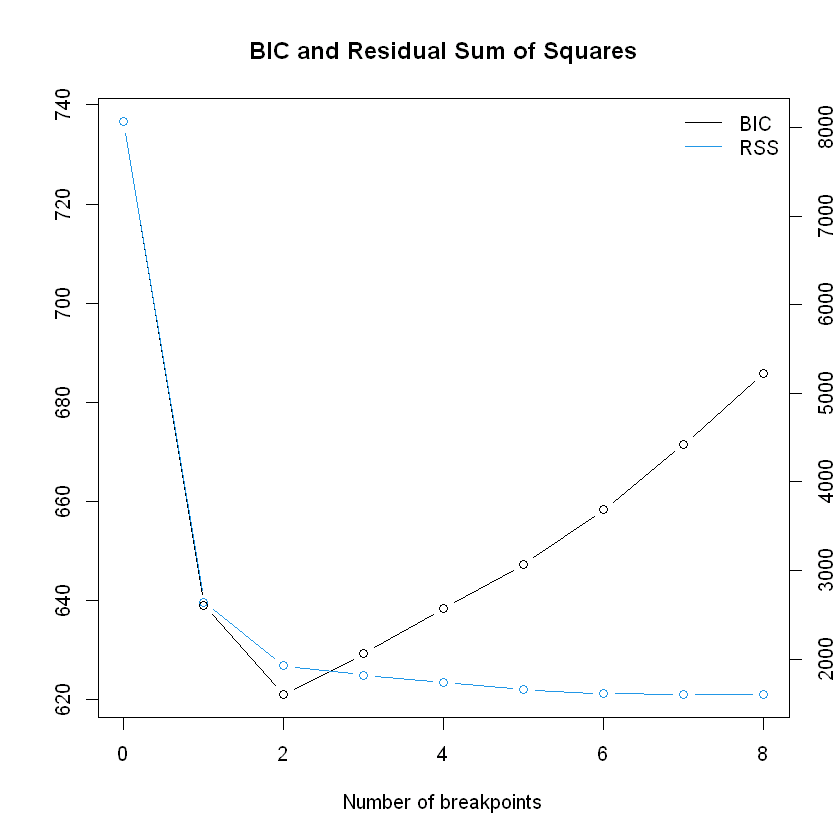

[1] "2012-06-01" "2015-10-01"


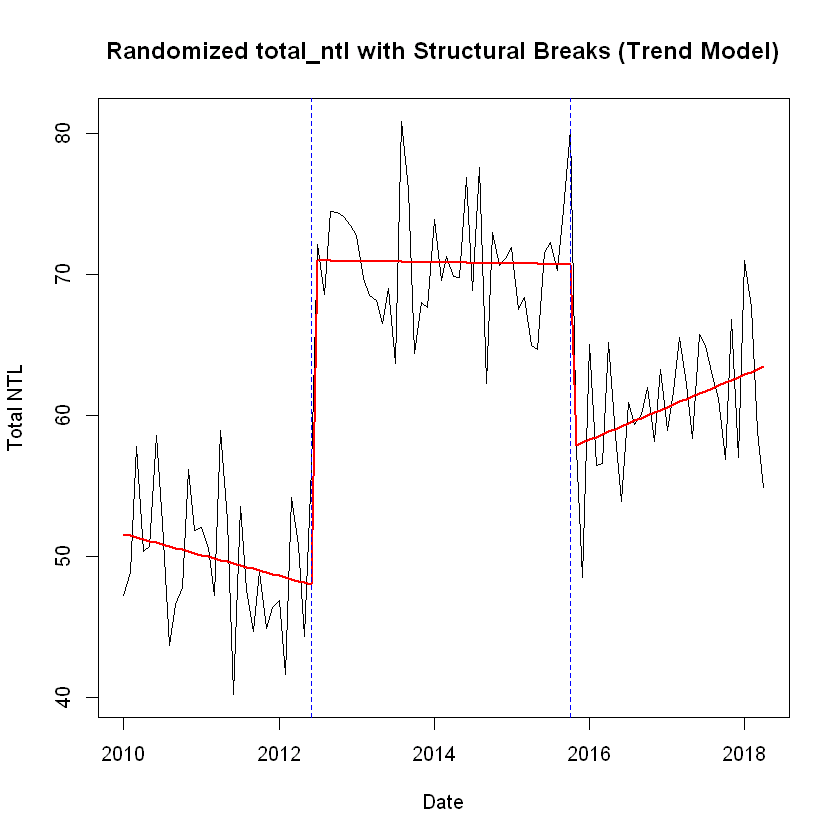

In [ ]:
# Load required package
library(strucchange)

# Set seed for reproducibility
set.seed(123)

# Generate a sequence of monthly dates
n <- 100
dates <- seq(as.Date("2010-01-01"), by = "month", length.out = n)

# Simulate total_ntl values with artificial breaks:
# - First 30 observations: mean ~50
# - Next 40 observations: mean ~70
# - Last 30 observations: mean ~60
total_ntl <- c(rnorm(30, mean = 50, sd = 5),
               rnorm(40, mean = 70, sd = 5),
               rnorm(30, mean = 60, sd = 5))

# Create the data frame
data <- data.frame(date = dates, total_ntl = total_ntl)

# Sort data by date and remove any potential NAs (should be none in this simulated dataset)
data <- data[order(data$date), ]
data <- na.omit(data)

# Create a numeric time index to represent time
data$time_index <- seq_len(nrow(data))

# Fit the Bai-Perron model (adjust h as needed)
bp_model <- breakpoints(total_ntl ~ time_index, data = data, h = 0.1)
plot(bp_model)
# Print a summary of the breakpoints
summary(bp_model)

# Get the fitted piecewise regression values
fitted_vals <- fitted(bp_model)

# Plot the original total_ntl time series and the fitted piecewise regression line
plot(data$date, data$total_ntl, type = "l",
     xlab = "Date", ylab = "Total NTL",
     main = "Randomized total_ntl with Structural Breaks (Trend Model)")
lines(data$date, fitted_vals, col = "red", lwd = 2)

# Get the breakpoints indices and corresponding dates
break_inds <- bp_model$breakpoints
break_dates <- data$date[break_inds]

# Draw vertical dashed blue lines at the estimated breakpoints
abline(v = break_dates, col = "blue", lty = 2)

# Print the break dates (x positions)
print(break_dates)
